<a href="https://colab.research.google.com/github/Atik1219/AI-with-AnyLogic-Running-Mode/blob/main/Hypertunning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Suppier_Disruption_LogTable_Coded1.csv to Suppier_Disruption_LogTable_Coded1.csv


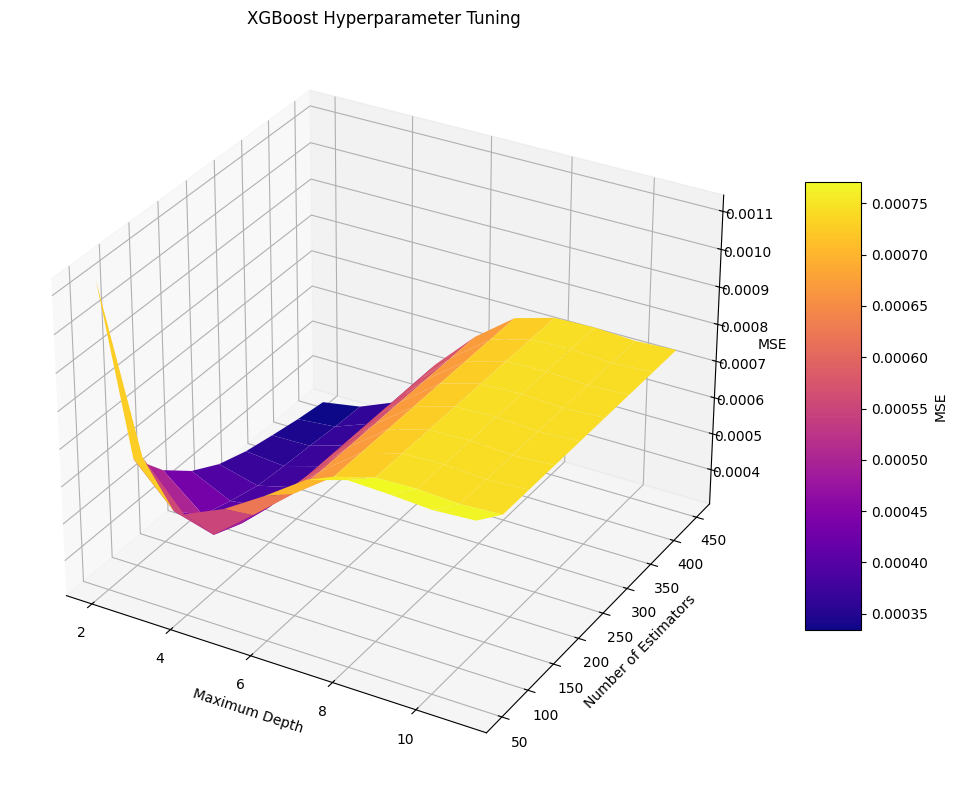

In [1]:
# ==========================================================
# 1️⃣ Imports
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

# ==========================================================
# 2️⃣ Load Dataset
# ==========================================================

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Suppier_Disruption_LogTable_Coded1.csv")

# Define features and target
features = [
    "kg_score",
    "Em_Score",
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
    "downtime_hours"
]

X = df[features]
y = df["high_disruption_p"]

# ==========================================================
# 3️⃣ Define Hyperparameter Grid
# ==========================================================

depth_range = np.arange(2, 12, 1)
estimators_range = np.arange(50, 500, 50)

depth_mesh, est_mesh = np.meshgrid(depth_range, estimators_range)
mse_scores = np.zeros_like(depth_mesh, dtype=float)

# ==========================================================
# 4️⃣ Grid Search Loop
# ==========================================================

for i in range(len(estimators_range)):
    for j in range(len(depth_range)):

        model = XGBRegressor(
            max_depth=depth_range[j],
            n_estimators=estimators_range[i],
            learning_rate=0.1,
            random_state=42,
            eval_metric="rmse"
        )

        # 5-fold cross-validation MSE
        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring="neg_mean_squared_error"
        )

        mse_scores[i, j] = -scores.mean()

# ==========================================================
# 5️⃣ 3D Surface Plot
# ==========================================================

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    depth_mesh,
    est_mesh,
    mse_scores,
    cmap="plasma",
    edgecolor='none'
)

ax.set_xlabel("Maximum Depth")
ax.set_ylabel("Number of Estimators")
ax.set_zlabel("MSE")

fig.colorbar(surf, shrink=0.6, aspect=8, label="MSE")

plt.title("XGBoost Hyperparameter Tuning")
plt.tight_layout()
plt.show()